# Runtime–quality trade-off for IMSTE

Sweep the number of minimum spanning trees (`n_msts`) and compare each fit by runtime and trustworthiness. Each setting is repeated 15 times on different stratified MNIST subsamples of the same size. Within a repeat, every `n_msts` value uses the same sample and estimator seed for a paired comparison. The scatter plot shows mean runtime and mean quality; error bars show run-to-run standard deviations.

Runtime measures `fit_transform` only; data loading and trustworthiness scoring are excluded. The defaults below use 8,000 MNIST samples, 200 epochs, and the project default of FAMST. IMSTE optimization uses the CPU Numba backend. The notebook does not require an MPS-capable Mac. Adjust the settings to explore another sample size or sweep.

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.manifold import trustworthiness

# Add the notebook helper module when running from the repository or notebooks/.
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "notebooks" / "digits_sweep.py").is_file()),
    None,
)
if repo_root is not None:
    sys.path.insert(0, str(repo_root / "notebooks"))

from digits_sweep import load_mnist_data
from imste import IteratedMinimumSpanningTreeEmbedder

## Prepare different samples for the repeats

The helper downloads and caches MNIST through OpenML. Each repeat gets a different stratified sample of the same size, with features standardized within that sample. Each sample is reused across the full `n_msts` sweep so settings are compared on matched data.

In [2]:
SAMPLE_SIZE = 8_000  # Number of MNIST rows per fit; None uses all 70,000.
N_REPEATS = 15
BASE_RANDOM_STATE = 42
REPEAT_SEEDS = [BASE_RANDOM_STATE + repeat for repeat in range(N_REPEATS)]
samples_by_seed = {
    seed: load_mnist_data(sample_size=SAMPLE_SIZE, random_state=seed)[0]
    for seed in REPEAT_SEEDS
}
print(
    f"Prepared {len(samples_by_seed)} samples of "
    f"{next(iter(samples_by_seed.values())).shape[0]:,} rows each."
)

Prepared 15 samples of 8,000 rows each.


## Configure and run the sweep

`N_MSTS_VALUES` is the parameter being swept. All other settings are held fixed, and each value is fitted `N_REPEATS` times with distinct seeds. `n_msts=15` and `n_epochs=200` match the current estimator defaults.

In [3]:
N_MSTS_VALUES = list(range(5, 31))  # Sweep every MST count from 5 through 30.
TRUSTWORTHINESS_NEIGHBORS = 10
BASE_PARAMS = {
    "n_epochs": 200,
    "device": "cpu",  # Run the Numba optimizer on CPU.
}

results = []
for n_msts in N_MSTS_VALUES:
    for repeat, seed in enumerate(REPEAT_SEEDS):
        X_repeat = samples_by_seed[seed]
        estimator = IteratedMinimumSpanningTreeEmbedder(
            n_msts=n_msts,
            random_state=seed,
            **BASE_PARAMS,
        )
        print(f"Fitting n_msts={n_msts}, repeat={repeat + 1}/{N_REPEATS} ...", flush=True)
        started = time.perf_counter()
        embedding = estimator.fit_transform(X_repeat)
        runtime_seconds = time.perf_counter() - started
        score = trustworthiness(
            X_repeat,
            embedding,
            n_neighbors=min(TRUSTWORTHINESS_NEIGHBORS, len(X_repeat) - 1),
        )
        results.append({
            "n_msts": n_msts,
            "repeat": repeat + 1,
            "seed": seed,
            "runtime_seconds": runtime_seconds,
            "trustworthiness": score,
            "device": estimator.device_,
        })
        print(
            f"  runtime={runtime_seconds:.2f}s, "
            f"trustworthiness={score:.4f}, device={estimator.device_}",
            flush=True,
        )

results_df = pd.DataFrame(results)
summary_df = (
    results_df.groupby("n_msts")
    .agg(
        runtime_mean=("runtime_seconds", "mean"),
        runtime_std=("runtime_seconds", "std"),
        trustworthiness_mean=("trustworthiness", "mean"),
        trustworthiness_std=("trustworthiness", "std"),
    )
    .reset_index()
)
summary_df

Fitting n_msts=5, repeat=1/15 ...
  runtime=7.64s, trustworthiness=0.7935, device=cpu
Fitting n_msts=5, repeat=2/15 ...
  runtime=1.19s, trustworthiness=0.7935, device=cpu
Fitting n_msts=5, repeat=3/15 ...
  runtime=1.17s, trustworthiness=0.7784, device=cpu
Fitting n_msts=5, repeat=4/15 ...
  runtime=1.18s, trustworthiness=0.7722, device=cpu
Fitting n_msts=5, repeat=5/15 ...
  runtime=1.17s, trustworthiness=0.7908, device=cpu
Fitting n_msts=5, repeat=6/15 ...
  runtime=1.32s, trustworthiness=0.7842, device=cpu
Fitting n_msts=5, repeat=7/15 ...
  runtime=1.22s, trustworthiness=0.7649, device=cpu
Fitting n_msts=5, repeat=8/15 ...
  runtime=1.18s, trustworthiness=0.7927, device=cpu
Fitting n_msts=5, repeat=9/15 ...
  runtime=1.19s, trustworthiness=0.7794, device=cpu
Fitting n_msts=5, repeat=10/15 ...
  runtime=1.15s, trustworthiness=0.7951, device=cpu
Fitting n_msts=5, repeat=11/15 ...
  runtime=1.19s, trustworthiness=0.7974, device=cpu
Fitting n_msts=5, repeat=12/15 ...
  runtime=1.19s, 

,n_msts,runtime_mean,runtime_std,trustworthiness_mean,trustworthiness_std
0,5,1.630541,1.662940,0.785199,0.010368
1,6,1.308890,0.028015,0.790505,0.013400
2,7,1.469316,0.150493,0.797585,0.011891
3,8,1.606326,0.120750,0.800116,0.012051
4,9,1.619601,0.154826,0.801984,0.015270
5,10,1.722109,0.199035,0.806537,0.012114
6,11,1.892417,0.285777,0.809634,0.011234
7,12,1.960657,0.348811,0.805110,0.011124
8,13,2.050589,0.360346,0.805522,0.011837
9,14,2.031946,0.228030,0.812202,0.010695


## Runtime versus trustworthiness

Each point is one `n_msts` setting, averaged over five runs. Horizontal and vertical error bars show one standard deviation in runtime and trustworthiness, respectively.

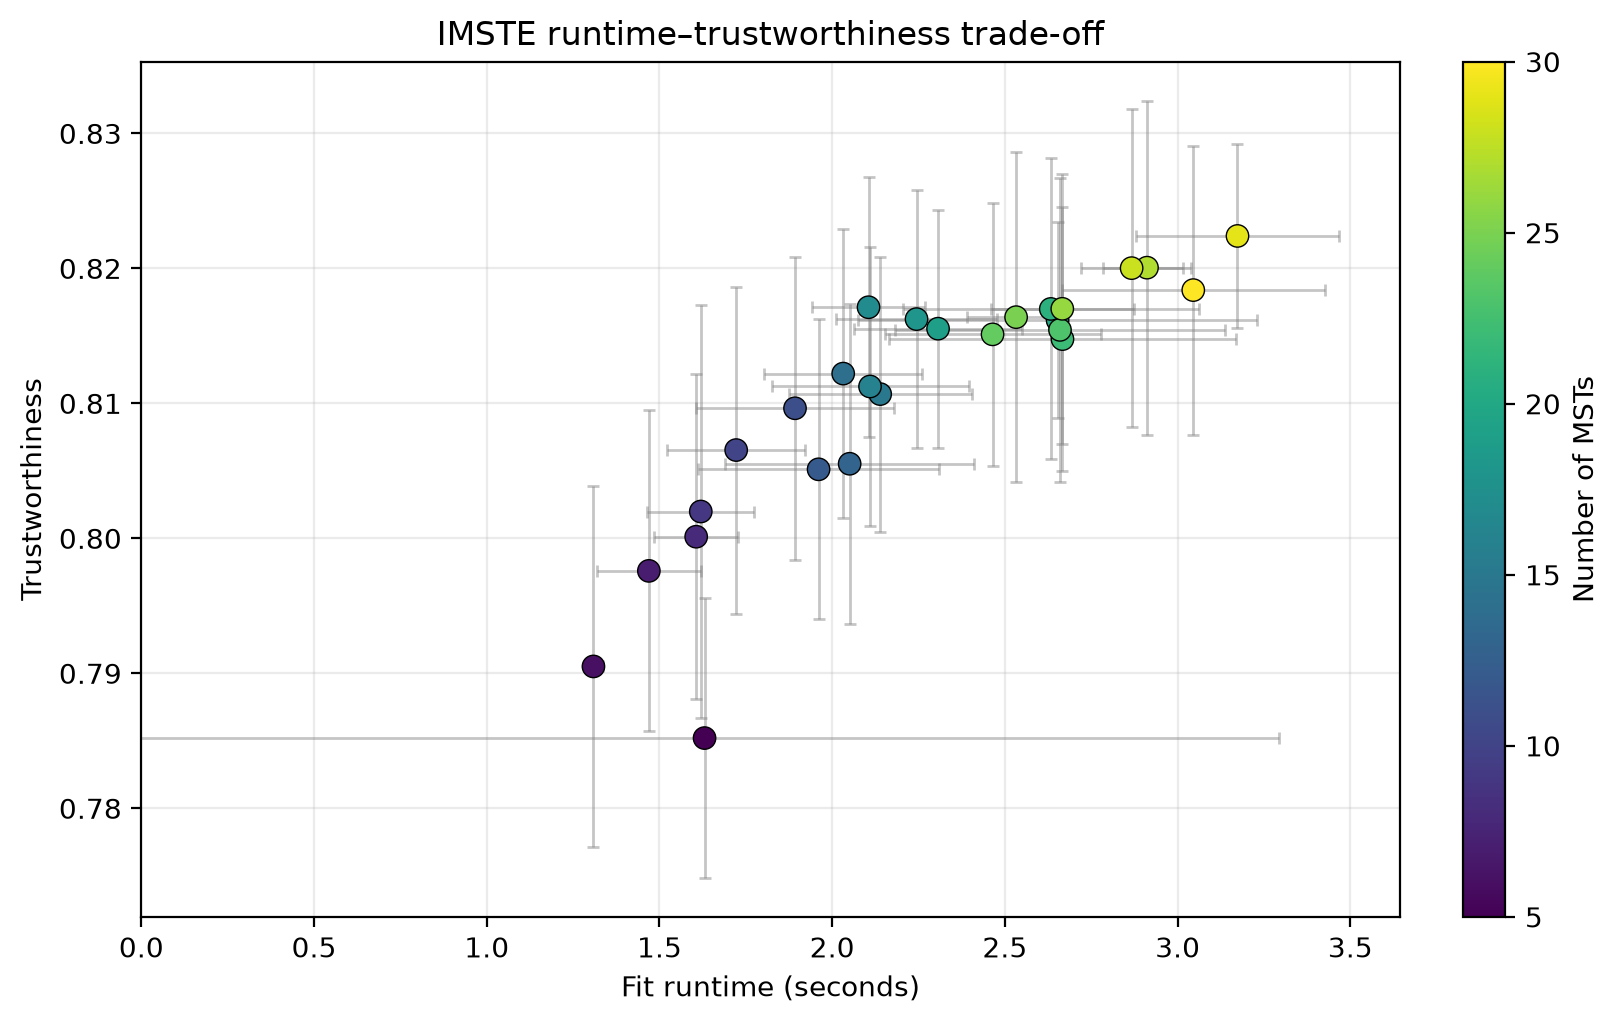

,n_msts,runtime_mean,runtime_std,trustworthiness_mean,trustworthiness_std
0,5,1.63,1.66,0.7852,0.0104
1,6,1.31,0.03,0.7905,0.0134
2,7,1.47,0.15,0.7976,0.0119
3,8,1.61,0.12,0.8001,0.0121
4,9,1.62,0.15,0.8020,0.0153
5,10,1.72,0.20,0.8065,0.0121
6,11,1.89,0.29,0.8096,0.0112
7,12,1.96,0.35,0.8051,0.0111
8,13,2.05,0.36,0.8055,0.0118
9,14,2.03,0.23,0.8122,0.0107


In [4]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
points = ax.scatter(
    summary_df["runtime_mean"],
    summary_df["trustworthiness_mean"],
    c=summary_df["n_msts"],
    cmap="viridis",
    s=65,
    edgecolor="black",
    linewidth=0.5,
    zorder=3,
)
ax.errorbar(
    summary_df["runtime_mean"],
    summary_df["trustworthiness_mean"],
    xerr=summary_df["runtime_std"],
    yerr=summary_df["trustworthiness_std"],
    fmt="none",
    ecolor="gray",
    elinewidth=1,
    capsize=2,
    alpha=0.45,
    zorder=2,
)
ax.set_xlim(left=0)
ax.set_xlabel("Fit runtime (seconds)")
ax.set_ylabel("Trustworthiness")
ax.set_title("IMSTE runtime–trustworthiness trade-off")
ax.grid(True, alpha=0.25)
colorbar = fig.colorbar(points, ax=ax, ticks=[5, 10, 15, 20, 25, 30])
colorbar.set_label("Number of MSTs")
plt.show()

summary_df.style.format({
    "runtime_mean": "{:.2f}",
    "runtime_std": "{:.2f}",
    "trustworthiness_mean": "{:.4f}",
    "trustworthiness_std": "{:.4f}",
})